# 07 · Deep learning: LSTM and Transformer

The models so far receive **hand-made summaries** of the past: the volatility of the last day, week, month... A neural network for sequences can instead read the **raw daily history** and learn by itself which patterns matter. This step tests two of them, written in PyTorch ([`src/models/deep.py`](../src/models/deep.py)):

| Model | How it reads the last 22 days |
|---|---|
| **LSTM** (*Long Short-Term Memory*) | Day by day, in order, keeping a memory of what it has seen |
| **Transformer** | All days at once: each day can look directly at every other day (*self-attention*) |

The benchmark is again **HAR-X** (why: section 7 of notebook 05). Here the comparison is especially clean: each network contains a HAR-X regression (see the architecture below), so its gap with HAR-X shows what reading the raw sequence adds on top of it.

### Architecture

```
tabular features of day t ─────────────────────┬──> linear layer ─────────────┐
                                               │                             (+)──> log variance for 1, 5 and 22 days
last 22 days ──> LSTM or Transformer ──> [concatenate] ──> small network ──────┘
```

* **Sequence input:** 22 days of 5 raw daily variables (variance, return, volume ratio, market variance, VIX).
* **Linear path:** a HAR-X regression inside the network, initialised with its least-squares solution. Training therefore *starts from HAR-X*, and the forecast can follow volatility to levels never seen in training (the lesson of Step 7).
* **Deep path:** starts at zero and learns what the linear part misses.
* **One network for the three horizons**, trained on QLIKE.

### Training without looking at the future

* The number of training passes over the data (*epochs*) is chosen by **early stopping** on the last year of the training window; the network is then retrained on the whole window.
* Features are standardised with the mean and standard deviation of the training rows only.
* A new network is trained for every test year, like the other models.

**Run first** (from the project root):
```bash
python -m pip install -r requirements-dl.txt     # PyTorch
python -m src.models.run_deep                     # a few hours on a CPU, much faster on a GPU
```

In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

from src.db import get_engine
from src.viz import AQUA, BLUE, CRISES, GRID, INK, INK_2, MUTED, ORANGE, save, set_style

set_style()
engine = get_engine()
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:,.3f}".format)

LABELS = {"naive": "Naive (last value)", "monthly_average": "Monthly average", "historical_mean": "Historical mean",
          "ewma": "EWMA of range-based variance", "riskmetrics": "RiskMetrics (EWMA of squared returns)",
          "garch": "GARCH(1,1)", "gjr_garch": "GJR-GARCH", "har": "HAR", "har_x": "HAR-X",
          "lgbm": "LightGBM", "lgbm_hybrid": "HAR-X + LightGBM", "lstm": "LSTM", "transformer": "Transformer"}
FAMILIES = {"deep_learning": ("Deep learning (Step 8)", AQUA), "machine_learning": ("Machine learning (Step 7)", ORANGE),
            "econometric": ("Econometric models (Step 6)", BLUE), "baseline": ("Baselines (Step 5)", MUTED)}
DEEP = ["lstm", "transformer"]

## 1. Training record

One line per training: the last day of the training window, the number of rows, the number of epochs selected by early stopping, the validation QLIKE at each horizon and the time it took.

In [2]:
parameters = pd.read_sql("SELECT * FROM model_parameters WHERE model IN ('lstm', 'transformer')", engine, parse_dates=["train_end"])
wide = parameters.pivot(index=["model", "horizon", "train_end"], columns="parameter", values="value").reset_index()
# one training gives one record per horizon (their training windows end a few days apart): number the trainings
wide["training"] = wide.groupby(["model", "horizon"])["train_end"].rank().astype(int)
first = wide[wide["horizon"] == 1].set_index(["model", "training"])
record = first[["n_train", "epochs", "training_seconds"]].rename(columns={"n_train": "training rows", "training_seconds": "seconds"})
record.insert(0, "first test year", first["train_end"].dt.year + 1)
scores = wide.pivot_table(index=["model", "training"], columns="horizon", values="validation_qlike")
scores.columns = [f"validation QLIKE, {h}d" for h in scores.columns]
display(record.join(scores).rename(index=LABELS, level="model"))
total = first.groupby("model")["training_seconds"].sum() / 60
print("Total training time (minutes):", {LABELS[m]: round(t, 1) for m, t in total.items()})

first test year  training rows  epochs   seconds  validation QLIKE, 1d  validation QLIKE, 5d  validation QLIKE, 22d
model       training                                                                                                                     
LSTM        1                    2006     78,965.000   8.000    55.311                 0.367                 0.184                  0.096
            2                    2007     93,131.000   1.000    14.708                 0.350                 0.180                  0.138
            3                    2008    107,437.000   1.000    16.975                 0.383                 0.232                  0.181
            4                    2009    121,926.000   9.000    75.126                 0.298                 0.187                  0.178
            5                    2010    136,750.000   3.000    34.643                 0.250                 0.125                  0.102
            6                    2011    151,802.000   1.000    20.023                 0.276                 0.153                  0.180
            7                    2012    166,782.000   1.000    22.564                 0.293                 0.178                  0.219
            8                    2013    181,717.000   1.000    24.138                 0.333                 0.174                  0.121
            9                    2014    196,593.000   8.000   109.204                 0.395                 0.212                  0.123
            10                   2015    211,474.000   3.000    52.664                 0.364                 0.197                  0.132
            11                   2016    226,405.000   4.000    69.503                 0.392                 0.240                  0.158
            12                   2017    241,403.000  10.000   152.144                 0.466                 0.291                  0.261
            13                   2018    256,319.000   6.000   109.284                 0.383                 0.200                  0.108
            14                   2019    271,228.000   1.000    36.098                 0.370                 0.225                  0.157
            15                   2020    286,097.000   3.000    71.386                 0.376                 0.196                  0.121
            16                   2021    301,110.000   3.000    75.931                 0.357                 0.244                  0.832
            17                   2022    316,154.000   5.000   118.172                 0.386                 0.211                  0.110
            18                   2023    331,160.000   1.000    42.792                 0.300                 0.153                  0.138
            19                   2024    346,098.000   1.000    45.199                 0.390                 0.226                  0.170
            20                   2025    361,089.000   6.000   155.400                 0.467                 0.263                  0.151
            21                   2026    375,987.000   4.000   116.965                 0.475                 0.364                  0.322
Transformer 1                    2006     78,965.000   3.000   236.533                 0.370                 0.187                  0.100
            2                    2007     93,131.000   1.000   138.538                 0.349                 0.179                  0.144
            3                    2008    107,437.000   1.000   162.064                 0.381                 0.232                  0.182
            4                    2009    121,926.000   2.000   277.760                 0.290                 0.188                  0.235
            5                    2010    136,750.000   3.000   422.698                 0.249                 0.118                  0.079
            6                    2011    151,802.000   1.000   230.582                 0.278                 0.157                  0.187
            7       

Total training time (minutes): {'LSTM': 23.6, 'Transformer': 277.1}


**Reading the table.**

* **Early stopping often stops after a single epoch** (8 of the 21 trainings of each network). The networks start from the HAR-X regression, and in those years a second pass over the data already made the validation loss worse: there was little left to learn beyond the linear model.
* **The number of epochs is unstable**, between 1 and 10 from one year to the next. One validation year is a small and noisy sample, the same weakness as in the tuning of LightGBM.
* **The validation year matters:** the networks trained for 2021 are validated on 2020 (COVID-19), with a 22-day validation QLIKE above 0.8, against 0.3 or less in the other years.
* **Cost:** about 24 minutes in total for the LSTM and about 4 hours 40 minutes for the Transformer on a laptop CPU, against a few seconds for HAR-X.

## 2. Results

All thirteen models, scored in SQL on their common sample (2006 to 2026).

In [3]:
overall = pd.read_sql("SELECT * FROM model_scores_overall", engine)
overall["model_label"] = overall["model"].map(LABELS)
print(f"Forecasts per model and horizon: about {overall['n_forecasts'].median():,.0f}")

def table(metric):
    t = overall.pivot(index="model_label", columns="horizon", values=metric)
    t.columns = [f"{h} day" + ("s" if h > 1 else "") for h in t.columns]
    return t.sort_values(t.columns[1])

print("\nQLIKE (lower is better)")
display(table("qlike"))
print("MAE in annualised volatility points")
display(table("mae_vol"))

Forecasts per model and horizon: about 306,931

QLIKE (lower is better)


,1 day,5 days,22 days
model_label,,,
HAR-X + LightGBM,0.371,0.220,0.214
HAR-X,0.378,0.220,0.199
LSTM,0.373,0.221,0.206
LightGBM,0.372,0.221,0.216
Transformer,0.372,0.222,0.212
HAR,0.400,0.242,0.212
GJR-GARCH,0.431,0.262,0.222
"GARCH(1,1)",0.441,0.271,0.226
EWMA of range-based variance,0.440,0.273,0.250


MAE in annualised volatility points


,1 day,5 days,22 days
model_label,,,
Transformer,7.964,6.302,6.156
HAR-X + LightGBM,7.914,6.399,6.569
LightGBM,7.928,6.402,6.543
HAR-X,8.126,6.409,6.236
LSTM,8.151,6.480,6.288
HAR,8.641,7.007,6.742
EWMA of range-based variance,8.951,7.121,6.608
GJR-GARCH,8.976,7.250,6.791
RiskMetrics (EWMA of squared returns),8.867,7.250,6.910


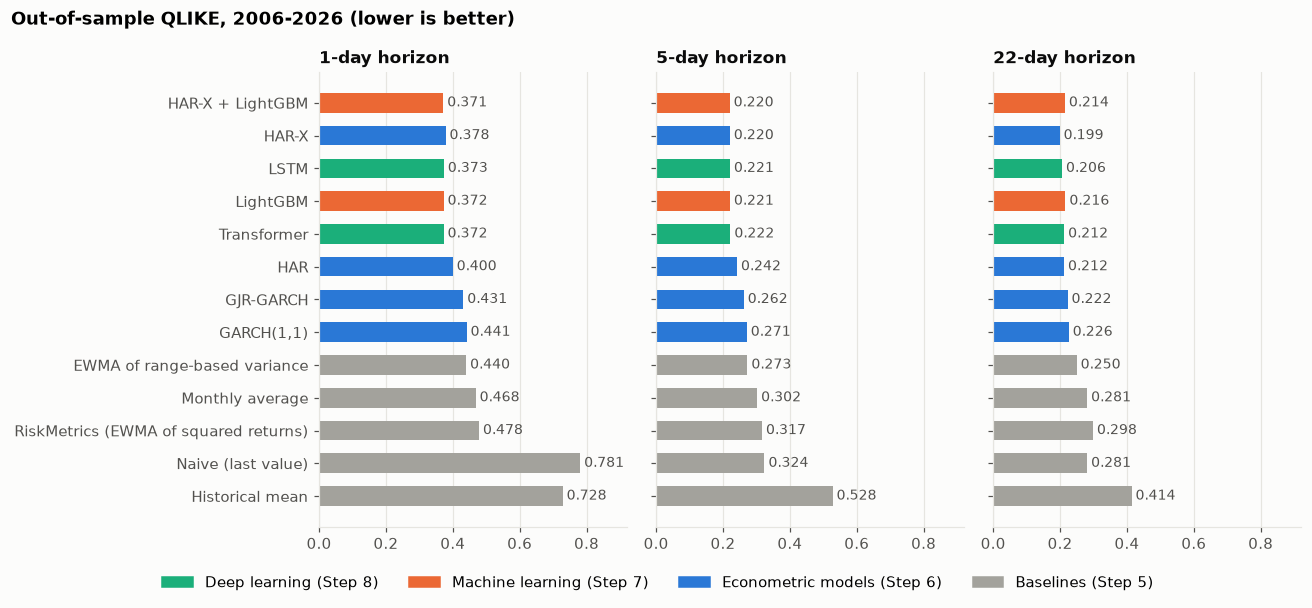

In [4]:
family = overall.drop_duplicates("model_label").set_index("model_label")["family"]
fig, axes = plt.subplots(1, 3, figsize=(12, 5.4), sharex=True)
order = table("qlike").index[::-1]
for ax, h in zip(axes, [1, 5, 22]):
    scores = overall[overall["horizon"] == h].set_index("model_label").loc[order, "qlike"]
    ax.barh(scores.index, scores.values, color=[FAMILIES[family[m]][1] for m in scores.index], height=0.6)
    for y, v in enumerate(scores.values):
        ax.text(v + 0.012, y, f"{v:.3f}", va="center", color=INK_2, fontsize=9)
    ax.set_title(f"{h}-day horizon", fontsize=11)
    ax.grid(axis="y", visible=False)
    if h != 1:
        ax.set_yticklabels([])
axes[0].set_xlim(0, overall["qlike"].max() * 1.18)
handles = [plt.Rectangle((0, 0), 1, 1, color=color) for _, color in FAMILIES.values()]
fig.legend(handles, [label for label, _ in FAMILIES.values()], loc="lower center", ncols=4, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Out-of-sample QLIKE, 2006-2026 (lower is better)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(rect=(0, 0.04, 1, 1))
save(fig, "08_model_scores")
plt.show()

In [5]:
# Change of each loss compared with HAR-X (negative = better than HAR-X)
reference = overall[overall["model"] == "har_x"].set_index("horizon")
rows = []
for model in DEEP + ["lgbm_hybrid"]:
    scores = overall[overall["model"] == model].set_index("horizon")
    for metric, label in [("qlike", "QLIKE"), ("log_mse", "log MSE"), ("mae_vol", "MAE")]:
        rows.append({"model": LABELS[model], "loss": label, **{f"{h} day" + ("s" if h > 1 else ""): scores.loc[h, metric] / reference.loc[h, metric] - 1 for h in (1, 5, 22)}})
display(pd.DataFrame(rows).set_index(["model", "loss"]).map("{:+.1%}".format))

1 day 5 days 22 days
model            loss                         
LSTM             QLIKE    -1.3%  +0.1%   +3.6%
                 log MSE  -0.7%  +0.2%   +1.3%
                 MAE      +0.3%  +1.1%   +0.8%
Transformer      QLIKE    -1.5%  +0.7%   +6.8%
                 log MSE  -2.9%  -2.1%   +1.7%
                 MAE      -2.0%  -1.7%   -1.3%
HAR-X + LightGBM QLIKE    -1.8%  -0.2%   +8.0%
                 log MSE  -3.7%  -1.2%   +8.2%
                 MAE      -2.6%  -0.2%   +5.3%

**Reading the results.** The pattern of Step 7 repeats itself:

* **1 day: slightly better than HAR-X.** QLIKE is 1.3% (LSTM) and 1.5% (Transformer) lower.
* **5 days: a tie.** Both networks are within 1% of HAR-X.
* **22 days: worse.** QLIKE is 3.6% (LSTM) and 6.8% (Transformer) higher than HAR-X, which remains the best model at that horizon.

Reading the raw 22-day sequence instead of hand-made summaries does not help: the day / week / month averages of HAR already contain what matters in the recent past.

**The two losses disagree about the Transformer:** it has the lowest mean absolute error of all thirteen models at 5 and 22 days, yet a worse QLIKE than HAR-X. Section 5 looks at this in detail, because it is the most instructive result of this step.

## 3. Where the models differ

5-day QLIKE of the two networks **relative to HAR-X**, for each test year: below zero, the network beat HAR-X that year.

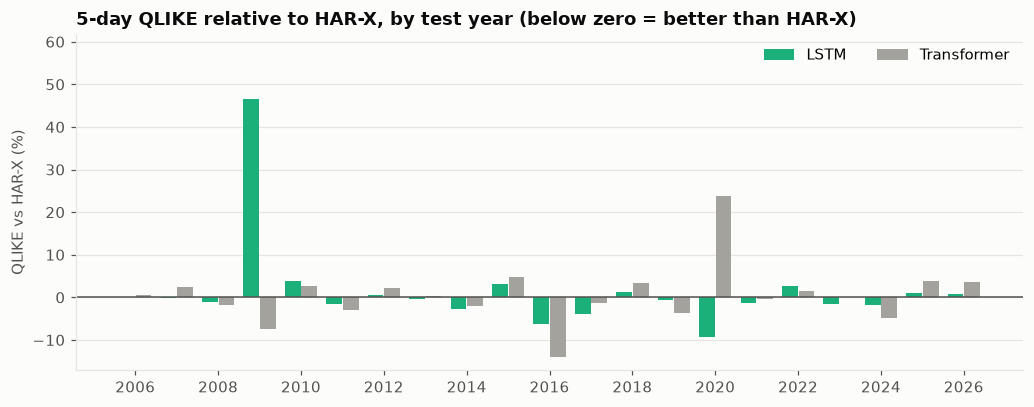

Test years in which the model beat HAR-X: {'LSTM': 12, 'Transformer': 9} out of 21


In [6]:
by_year = pd.read_sql("""
    SELECT model, test_year, sum(qlike * n) / sum(n) AS qlike
    FROM model_scores WHERE horizon = 5 AND model IN ('har_x', 'lstm', 'transformer')
    GROUP BY model, test_year""", engine).pivot(index="test_year", columns="model", values="qlike")
relative = (by_year[DEEP].div(by_year["har_x"], axis=0) - 1) * 100

fig, ax = plt.subplots(figsize=(9.5, 3.8))
x = np.arange(len(relative))
for i, (model, color) in enumerate([("lstm", AQUA), ("transformer", MUTED)]):
    ax.bar(x + (i - 0.5) * 0.4, relative[model], width=0.38, color=color, label=LABELS[model])
ax.axhline(0, color=INK_2, lw=1)
ax.set_xticks(x[::2], relative.index[::2])
ax.grid(axis="x", visible=False)
ax.set_ylabel("QLIKE vs HAR-X (%)")
ax.set_title("5-day QLIKE relative to HAR-X, by test year (below zero = better than HAR-X)")
low, high = relative.min().min(), relative.max().max()
ax.set_ylim(min(low, 0) - 0.05 * (high - low), high + 0.25 * (high - low))    # headroom for the legend
ax.legend(loc="upper right", ncols=2)
fig.tight_layout()
save(fig, "08_vs_harx_by_year")
plt.show()
print("Test years in which the model beat HAR-X:", (relative < 0).sum().rename(LABELS).to_dict(), "out of", len(relative))

In [7]:
stress = " OR ".join(f"f.date BETWEEN '{start}' AND '{end}'" for start, end in CRISES.values())
shown = ["har_x", "lgbm_hybrid", "lstm", "transformer"]
columns = ", ".join(f"avg(exp(x.target_5d) / f.{m} - ln(exp(x.target_5d) / f.{m}) - 1) AS qlike_{m}, avg(exp(x.target_5d) / f.{m}) AS bias_{m}" for m in shown)
complete = " AND ".join(f"f.{m} IS NOT NULL" for m in overall["model"].unique())
groups = pd.read_sql(f"""
    SELECT CASE WHEN {stress} THEN 'stress periods' ELSE 'calm periods' END AS regime, u.asset_type, count(*) AS n, {columns}
    FROM forecasts f JOIN features x USING (ticker, date) JOIN universe u USING (ticker)
    WHERE f.horizon = 5 AND x.target_5d IS NOT NULL AND {complete}
    GROUP BY 1, 2""", engine)

def weighted(by, prefix):
    out = {}
    for key, g in groups.groupby(by):
        out[key] = {LABELS[m]: np.average(g[f"{prefix}_{m}"], weights=g["n"]) for m in shown}
    return pd.DataFrame(out)

print("QLIKE at the 5-day horizon")
display(weighted("regime", "qlike").join(weighted("asset_type", "qlike")[["stock", "index"]].rename(columns={"stock": "stocks", "index": "indices"})))
print("Average of actual / forecast at the 5-day horizon (1 = no bias, below 1 = forecasts too high)")
display(weighted("asset_type", "bias")[["stock", "index"]].rename(columns={"stock": "stocks", "index": "indices"}))

QLIKE at the 5-day horizon


,calm periods,stress periods,stocks,indices
HAR-X,0.225,0.200,0.228,0.179
HAR-X + LightGBM,0.224,0.202,0.228,0.174
LSTM,0.225,0.204,0.228,0.177
Transformer,0.223,0.215,0.229,0.181


Average of actual / forecast at the 5-day horizon (1 = no bias, below 1 = forecasts too high)


,stocks,indices
HAR-X,1.061,0.945
HAR-X + LightGBM,1.063,1.040
LSTM,1.058,1.054
Transformer,1.077,1.073


**Reading the chart and the tables.**

* **Neural networks have occasional large failures.** In most years both networks are within a few percent of HAR-X, but the LSTM is 47% worse in **2009** and the Transformer 24% worse in **2020**. One such year is enough to cancel the small gains of all the others: the LSTM beats HAR-X in 12 test years out of 21 and still ends level with it.
* The LSTM of 2009 was trained on a window ending with the 2008 crisis, validated on 2008 itself, and ran for 9 epochs: it learned the crisis and applied it to the recovery. HAR-X, with 18 coefficients, cannot over-learn a single year in that way.
* **In stress periods HAR-X is the best** (0.200), the LSTM is close (0.204) and the Transformer clearly behind (0.215). In calm periods the three are equivalent, with a slight edge for the Transformer.
* **Like LightGBM, both networks remove the bias on indices** (actual / forecast of 1.05 to 1.07 instead of 0.945), thanks to the `is_index` feature.

## 4. What the forecasts look like

Five-day-ahead forecasts for the CAC 40 around the COVID-19 crash.

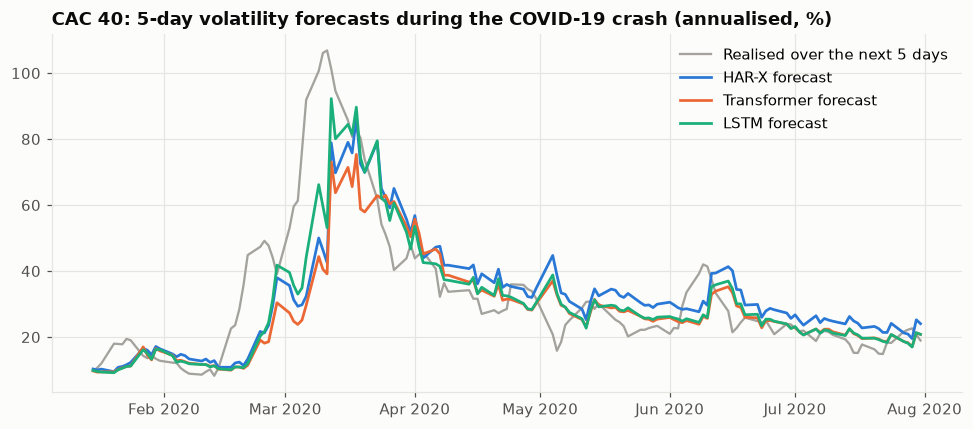

Correlation between the forecasts of the models (5-day horizon, this example):


model,HAR-X,LSTM,Transformer
model,,,
HAR-X,1.000,0.978,0.990
LSTM,0.978,1.000,0.967
Transformer,0.990,0.967,1.000


In [8]:
example = pd.read_sql("""
    SELECT model, date, pred_vol_pct, actual_vol_pct FROM forecast_vs_actual
    WHERE ticker = '^FCHI' AND horizon = 5 AND date BETWEEN '2020-01-15' AND '2020-07-31'
      AND model IN ('har_x', 'lstm', 'transformer')""", engine, parse_dates=["date"])
actual = example[example["model"] == "har_x"].set_index("date")["actual_vol_pct"].sort_index()
pred = example.pivot(index="date", columns="model", values="pred_vol_pct").sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(actual.index, actual, color=MUTED, lw=1.5, label="Realised over the next 5 days")
for model, color in [("har_x", BLUE), ("transformer", ORANGE), ("lstm", AQUA)]:
    ax.plot(pred.index, pred[model], color=color, lw=1.8, label=f"{LABELS[model]} forecast")
ax.set_title("CAC 40: 5-day volatility forecasts during the COVID-19 crash (annualised, %)")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.legend(loc="upper right")
fig.tight_layout()
save(fig, "08_forecast_example")
plt.show()
print("Correlation between the forecasts of the models (5-day horizon, this example):")
display(pred.rename(columns=LABELS).corr())

The three forecasts are almost the same curve: their correlation is 0.97 to 0.99. The networks are, in practice, HAR-X with small adjustments, which is what their design intends and what the data supports.

The differences appear at the peak of the crisis: the **LSTM reacts the most** to the first large falls of March, while the **Transformer stays well below** the other two around the peak. This is the under-prediction in turbulent markets that QLIKE penalises, and the reason for its poor score in 2020.

Note that this is one index in one crisis. Over the whole of 2020 the LSTM is 9% better than HAR-X, but it was 47% worse in 2009: a model can be the best in one crisis and the worst in the next. Over all stress periods together, HAR-X remains ahead (0.200 against 0.204).

## 5. The most accurate model on average is not the safest one

The Transformer is a good illustration of why the choice of the loss function matters. Compared with HAR-X, at the 5-day and 22-day horizons:

| | MAE, 5 days | MAE, 22 days | QLIKE, 5 days | QLIKE, 22 days | QLIKE in calm periods | QLIKE in stress periods |
|---|---|---|---|---|---|---|
| Transformer | **6.30** | **6.16** | 0.222 | 0.212 | **0.223** | 0.215 |
| HAR-X | 6.41 | 6.24 | **0.220** | **0.199** | 0.225 | **0.200** |
| Winner | Transformer | Transformer | HAR-X | HAR-X | Transformer | HAR-X |

By the mean absolute error, the Transformer is **the best of the thirteen models**. By QLIKE, it is behind HAR-X, by 7% at 22 days. Both statements are true: the two losses do not measure the same thing.

**Why they disagree.** Take two forecasts that are wrong by the same 20 volatility points:

| Forecast | Outcome | Absolute error | QLIKE |
|---|---|---|---|
| 40% | 20% (risk over-estimated) | 20 points | 0.64 |
| 20% | 40% (risk under-estimated) | 20 points | 1.61 |

For MAE the two errors are identical. For QLIKE, **under-estimating risk costs two and a half times more**. A model that is very close on the many ordinary days, and too low on the few days when volatility jumps, therefore gets an excellent MAE and a poor QLIKE. That is the Transformer: the best in calm periods, clearly the worst of the four in stress periods, and well below the others at the peak of the COVID-19 crash.

**Why it matters in practice.** A volatility forecast is mostly used to size risk: a Value-at-Risk limit, a capital buffer, the size of a position. With a forecast that is too high, some capital sits idle. With a forecast that is too low in a crisis, losses exceed what was provisioned, at the worst possible moment. The two errors do not have the same cost, and a loss function that treats them equally would select the wrong model.

This is why QLIKE was fixed as the primary loss in Step 5, **before** any model was run: choosing the loss after seeing the results would allow almost any model to be declared the winner. Step 10 checks this conclusion directly, by backtesting Value-at-Risk with each model's forecasts.

## Summary

* **Deep learning does not beat HAR-X either.** Both networks are slightly better at 1 day (QLIKE about 1.4% lower), level at 5 days and worse at 22 days (+3.6% for the LSTM, +6.8% for the Transformer).
* **The most accurate model on average is not the safest one.** The Transformer has the lowest mean absolute error of all thirteen models at 5 and 22 days, but it under-predicts in crises, which QLIKE penalises and MAE does not. Which model is "best" depends on the loss, so the loss has to be chosen for the use case, and before looking at the results. For risk management, where under-estimating risk is the costly error, QLIKE is the right judge.
* **The LSTM is the better of the two here:** closer to HAR-X on QLIKE, more robust in stress periods, and twelve times faster to train. A sequence of 22 days is too short for the Transformer's strength (linking distant points) to matter.
* **More complex models fail in a different way:** not by being slightly worse everywhere, but by rare, large errors in years that differ from what they were trained on (2009, 2020).
* **Across three families** (econometric, tree-based, neural), the forecasts converge to the same level of accuracy: what remains is mostly unpredictable.

**Limitations.** The size of the networks (32 hidden units) and the length of the sequence (22 days) were chosen by judgement, not tuned, and each network was trained once (one random seed). The conclusion is therefore about networks of this kind and size, not about every possible architecture.

Next: Step 9 compares all thirteen models with statistical tests (are the differences significant?) and forecast combinations.